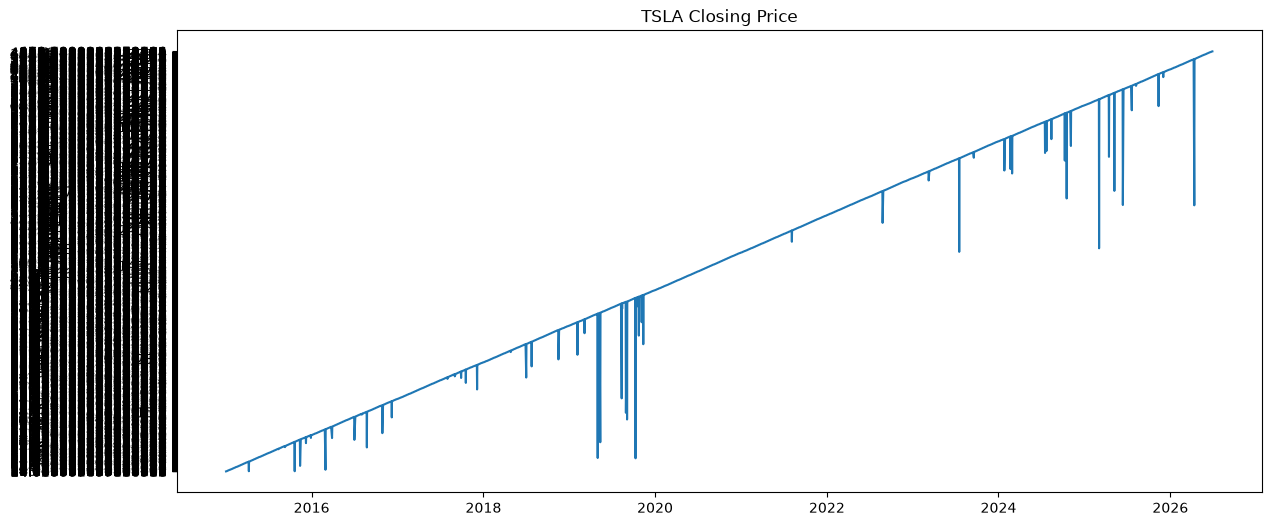

(2310, 1) (578, 1)


In [62]:
#Prepare TSLA dataset only
import pandas as pd

df = pd.read_csv("../data/processed/stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

tsla = df[df["Ticker"] == "TSLA"].copy()

tsla = tsla[["Date", "Close"]]
tsla.set_index("Date", inplace=True)

tsla.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(tsla["Close"])
plt.title("TSLA Closing Price")
plt.show()

#test/train split
train_size = int(len(tsla) * 0.8)

train = tsla.iloc[:train_size]
test = tsla.iloc[train_size:]

print(train.shape, test.shape)



Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14614.905, Time=1.89 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=0.30 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=1.04 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.749 seconds


c:\Users\Test\PycharmProjects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Test\PycharmProjects\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


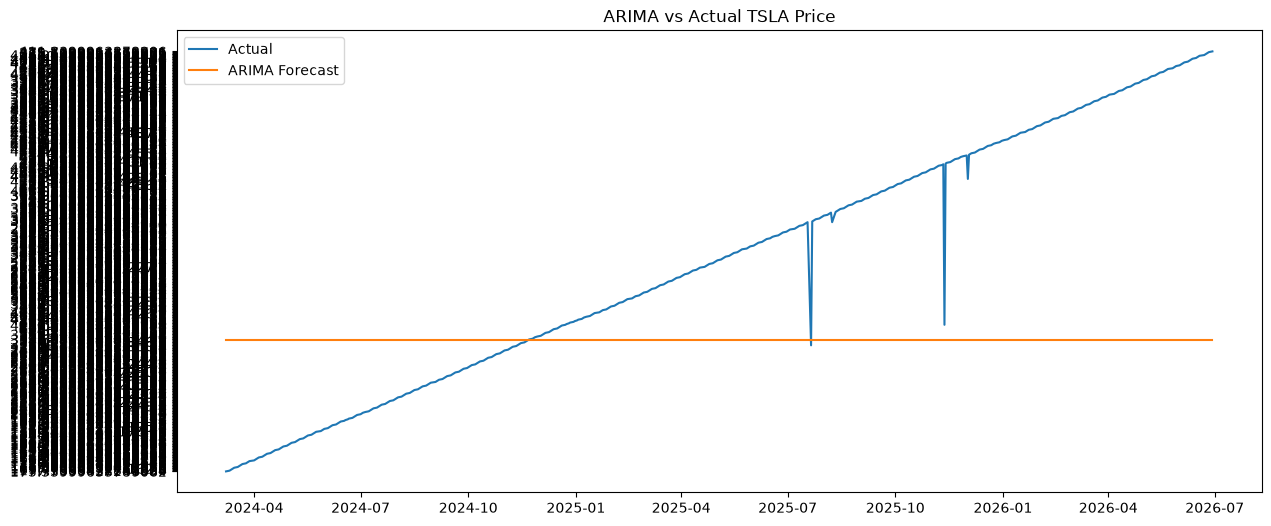

In [63]:
#Auto ARIMA

from pmdarima import auto_arima

model_arima = auto_arima(
    train["Close"],
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

model_arima.summary()

#auto arima forcast

n_periods = len(test)

forecast_arima = model_arima.predict(n_periods=n_periods)

forecast_arima
plt.figure(figsize=(14,6))

plt.plot(test.index, test["Close"], label="Actual")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA vs Actual TSLA Price")
plt.show()



In [ ]:
#Prepare LSTM Data

from sklearn.preprocessing import MinMaxScaler
import numpy as np


X, y = create_sequences(scaled_data)

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

prices = tsla["Close"].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(prices)

#Create sequences (60-day window)
def create_sequences(data, window=60):
    X, y = [], []

    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# train a/split 
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

y_train = y_train.view(-1, 1)
y_test = y_test.view(-1, 1)

import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer (2 stacked layers like your TensorFlow model)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected layer (Dense(1))
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, features)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))

        # take last time step (like return_sequences=False final layer)
        out = self.fc(out[:, -1, :])

        return out


model = LSTMModel()

print(model)




LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


C:\Users\Test\AppData\Local\Temp\ipykernel_14132\2591320203.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\Test\AppData\Local\Temp\ipykernel_14132\2591320203.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\Test\AppData\Local\Temp\ipykernel_14132\2591320203.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
C:\Users\Test\AppData\Local\Temp\ipykernel_14132

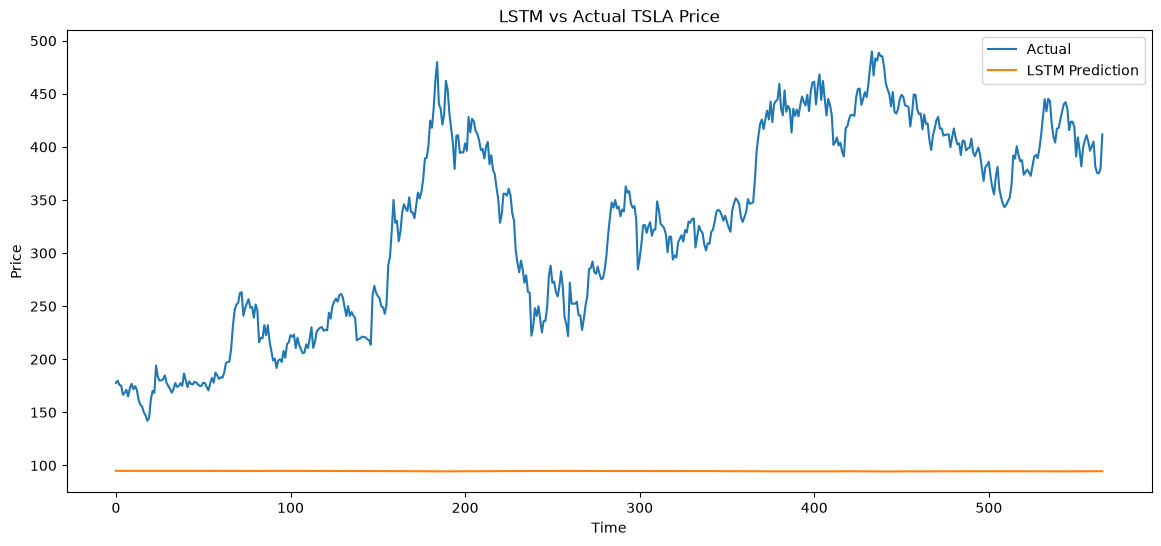

In [65]:
import matplotlib.pyplot as plt
import torch

# Put the model in evaluation mode
model.eval()

# Make predictions
with torch.no_grad():
    predictions = model(X_test)

# Convert tensors to NumPy arrays
predictions = predictions.numpy()
y_test_actual = y_test.numpy()

# Convert scaled values back to original prices
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test_actual)

# Plot results
plt.figure(figsize=(14, 6))

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="LSTM Prediction")

plt.title("LSTM vs Actual TSLA Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

In [66]:
#eveluation metrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE: 232.8545684814453
RMSE: 250.6429310917226
MAPE: 68.141594
